In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.2f}'.format)

# Part A - Data Preparation

### 1. Load both datasets:

In [2]:
bitcoin_df = pd.read_csv('fear_greed_index.csv')
historical_trader_df = pd.read_csv('historical_data.csv')

In [5]:
cols = ['Timestamp']
historical_trader_df[cols] = (historical_trader_df[cols]/1000).astype('int64')

### Shape of Datasets

In [6]:
bitcoin_df.shape, historical_trader_df.shape

((2644, 4), (211224, 16))

### Datasets info

In [ ]:
bitcoin_df.info()

In [ ]:
historical_trader_df.info()

### Missing Values

In [9]:
bitcoin_df.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
historical_trader_df.isna().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

### Duplicates

In [11]:
bitcoin_df.duplicated().any(), bitcoin_df.duplicated().sum()

(False, 0)

In [12]:
historical_trader_df.duplicated().any(), historical_trader_df.duplicated().sum()

(False, 0)

### 2. Convert timestamps and align the datasets by date 

In [13]:
bitcoin_df['date'] = pd.to_datetime(bitcoin_df['date'])
historical_trader_df['Timestamp IST'] = pd.to_datetime(historical_trader_df['Timestamp IST'], format="%d-%m-%Y %H:%M")

In [14]:
bitcoin_df = bitcoin_df.sort_values(by='date')
historical_trader_df = historical_trader_df.sort_values(by='Timestamp IST')

### 3. Create the key metrics you will analyze

In [15]:
historical_trader_df['Date'] = historical_trader_df['Timestamp IST'].dt.date

In [16]:
# daily PnL per trader (or per account)
daily_report = historical_trader_df.groupby(['Account', 'Date']).agg(
    total_daily_pnl = ('Closed PnL', 'sum'),
    trade_count=('Trade ID', 'count'),
    average_trade_size=('Size USD', 'mean')).reset_index()

In [17]:
# win rate
historical_trader_df['is_win'] = (historical_trader_df['Closed PnL'] > 0).astype(int)

win_count = (
    historical_trader_df
    .groupby(['Account', 'Date'])['is_win']
    .sum()
    .reset_index(name='win_count')
)

daily_report = daily_report.merge(win_count, on=['Account', 'Date'], how='left').fillna(0)

In [18]:
daily_report['win_rate'] = ((daily_report['win_count']/daily_report['trade_count'].replace(0,1))*100).round(2)

# changed daily_report'[date]' datatype from object to datetime64

daily_report['Date'] = pd.to_datetime(daily_report['Date'])

In [19]:
# finding long/short ratio
historical_trader_df['is_long'] = (historical_trader_df['Side'] == 'BUY').astype(int)
historical_trader_df['is_short'] = (historical_trader_df['Side'] == 'SELL').astype(int)

In [20]:
## Aggregating ls ratio per date and account
ls_ratio = historical_trader_df.groupby(['Account', 'Date', ])[['is_long', 'is_short']].sum().reset_index()
ls_ratio['long_short_ratio'] = np.where(
    ls_ratio['is_short'] == 0,
    np.nan,
    ls_ratio['is_long'] / ls_ratio['is_short']
).round(2)
ls_ratio['Date'] = pd.to_datetime(ls_ratio['Date'])

In [28]:
# merged with bitcoin dataset on dates (many-to-one mapping)
daily_report = daily_report.merge(bitcoin_df[['date', 'classification']], left_on='Date', right_on='date', how='inner')

In [32]:
# Drawdown proxy (loss rate)
daily_report['loss_flag'] = (daily_report['total_daily_pnl'] < 0).astype(int)

# aggregating per trader
drawdown_proxy = (daily_report.groupby('Account')['loss_flag'].mean().reset_index(name='loss_rate'))

# merge back to daily report
daily_report = daily_report.merge(drawdown_proxy, on='Account', how='left')

In [34]:
# consistency metric
consistency = (
    daily_report
    .groupby('Account')['win_rate']
    .std()
    .reset_index(name='win_rate_std')
)

# merge back to daily report
daily_report = daily_report.merge(consistency, on='Account', how='left')

In [36]:
# leverage 
volume = (
    historical_trader_df
    .groupby(['Account', 'Date'])['Size USD']
    .sum()
    .reset_index(name='total_volume')
)
volume['Date'] = pd.to_datetime(volume['Date'])

# merge back to daily report
daily_report = daily_report.merge(volume, on=['Account', 'Date'], how='left')

In [38]:
final_assignment_data = daily_report.merge(ls_ratio, on=['Account', 'Date'], how='left')

In [40]:
final_assignment_data = final_assignment_data.drop(columns='date')
final_assignment_data = final_assignment_data.rename(columns={'classification': 'sentiment'})

In [42]:
final_assignment_data.shape

(2340, 15)

### **Part A: Data Preparation - Documentation**

- **Dataset Dimensions:** The Bitcoin Sentiment dataset contains **2,644 rows**, while the Historical Trader dataset contains **211,224 rows**.  

- **Data Integrity:** A thorough audit confirmed no missing values or duplicate records in either dataset. However, the **leverage** column requested in the prompt was **not available in the source data**.  

- **Datatype Correction:** The `date` and `Timestamp IST` columns were converted from object types to **datetime** format. A `Date_Only` feature was engineered to facilitate daily-level alignment.  

- **Metric Engineering (Aggregation):** To transform raw transaction logs into actionable insights, the 211,224 trade records were grouped by **Account** and **Date** to compute the following daily metrics:  
  - **Daily PnL:** Total profit or loss per account.  
  - **Win Rate:** Percentage of trades where `Closed PnL > 0`.  
  - **Trade Frequency:** Total number of trades executed per day.  
  - **Average Trade Size:** Mean USD value per position.  
  - **Long/Short Ratio:** Ratio of buy versus sell trades.  

- **Additional Risk & Behavior Metrics:**  
  - **Drawdown Proxy (Loss Rate):** Percentage of days with negative PnL, used as a proxy for downside risk.  
  - **Consistency Metric:** Standard deviation of win rate per trader to capture performance stability.  
  - **Total Trading Volume:** Daily sum of `Size USD`, used as a proxy for trading intensity.  

- **⚠️ Leverage Proxy Note:**  
  Since the **leverage** column was missing from the dataset, **average trade size** and **total trading volume** were used as **proxies for leverage and risk exposure**. This assumption allows analysis of trading intensity despite the absence of explicit leverage data.  

- **Final Dataset Alignment:** An **inner join** was performed between the daily trader summaries and the Bitcoin sentiment dataset to ensure consistent date-level mapping.  

- **Outcome:** The final processed dataset contains **2,340 rows and 15 columns**, providing a clean and analysis-ready view of trader behavior aligned with market sentiment.

# Part B — Analysis

### Q1: Does performance differ between Fear vs Greed?

In [73]:
perf_summary = final_assignment_data.groupby('sentiment')[[
    'total_daily_pnl',
    'win_rate',
    'loss_rate'
]].agg(['mean', 'median'])

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

perf_summary = perf_summary.loc[order]
perf_summary

total_daily_pnl        win_rate        loss_rate       
                         mean median     mean median      mean median
sentiment                                                            
Extreme Fear          4619.44 218.38    32.97  30.77      0.11   0.11
Fear                  5328.82 107.89    36.40  31.53      0.10   0.09
Neutral               3438.62 167.55    35.54  32.11      0.09   0.09
Greed                 3318.10 158.21    34.36  28.92      0.09   0.08
Extreme Greed         5161.92 418.32    38.64  35.71      0.10   0.08

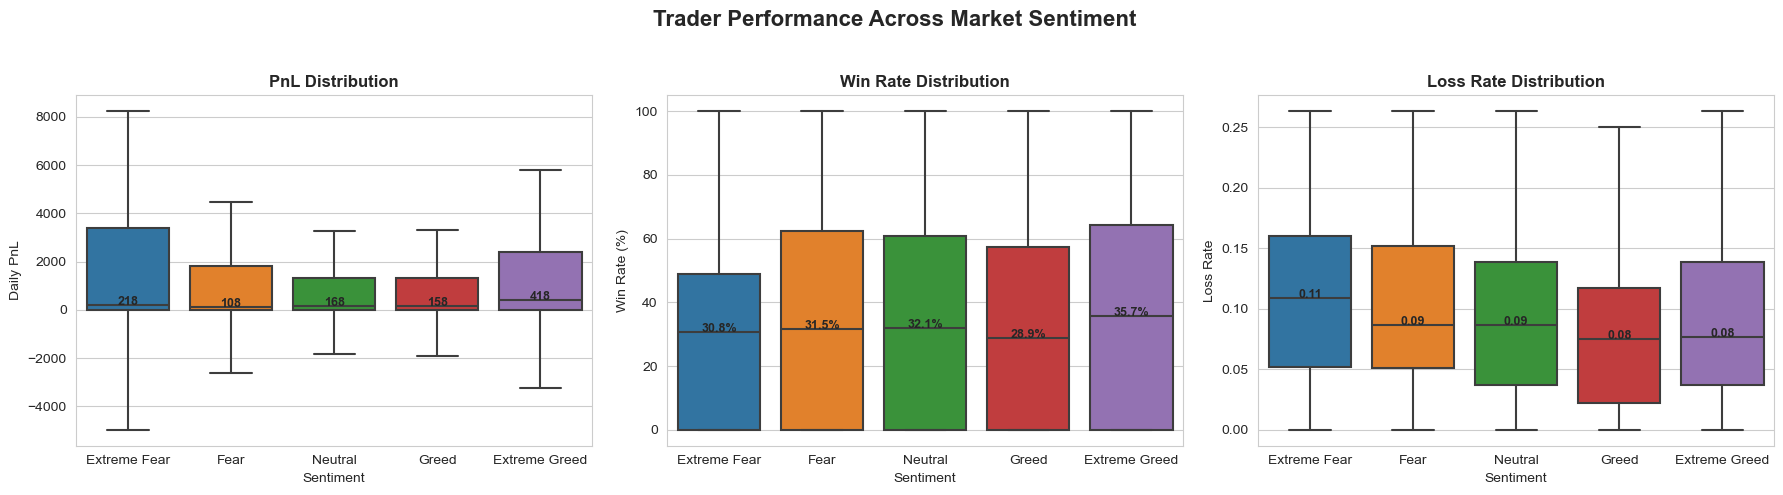

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ----------- 1. PnL -----------
sns.boxplot(
    data=final_assignment_data,
    x='sentiment',
    y='total_daily_pnl',
    order=order,
    showfliers=False,
    ax=axes[0]
)

axes[0].set_title("PnL Distribution", fontsize=12, weight='bold')
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Daily PnL")
axes[0].tick_params(axis='x')

# Median labels
medians_pnl = final_assignment_data.groupby('sentiment')['total_daily_pnl'].median().loc[order]
for i, median in enumerate(medians_pnl):
    axes[0].text(i, median, f'{median:.0f}', ha='center', size=9, weight='bold')


# ----------- 2. Win Rate -----------
sns.boxplot(
    data=final_assignment_data,
    x='sentiment',
    y='win_rate',
    order=order,
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title("Win Rate Distribution", fontsize=12, weight='bold')
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Win Rate (%)")
axes[1].tick_params(axis='x')

medians_win = final_assignment_data.groupby('sentiment')['win_rate'].median().loc[order]
for i, median in enumerate(medians_win):
    axes[1].text(i, median, f'{median:.1f}%', ha='center', size=9, weight='bold')


# ----------- 3. Loss Rate -----------
sns.boxplot(
    data=final_assignment_data,
    x='sentiment',
    y='loss_rate',
    order=order,
    showfliers=False,
    ax=axes[2]
)

axes[2].set_title("Loss Rate Distribution", fontsize=12, weight='bold')
axes[2].set_xlabel("Sentiment")
axes[2].set_ylabel("Loss Rate")
axes[2].tick_params(axis='x')

medians_loss = final_assignment_data.groupby('sentiment')['loss_rate'].median().loc[order]
for i, median in enumerate(medians_loss):
    axes[2].text(i, median, f'{median:.2f}', ha='center', size=9, weight='bold')


# Layout
plt.suptitle("Trader Performance Across Market Sentiment", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

Trader performance varies across sentiment regimes, with clearer nuances emerging when both **average (mean)** and **typical (median)** values are considered.

---

- **Profitability (PnL):**  
  The highest **average PnL** occurs during **Fear (5328.82)** and **Extreme Greed (5161.92)**, confirming strong opportunity in both volatile and strongly trending markets.  

  However, **median PnL tells a different story**:
  - **Extreme Greed (418.32)** has by far the highest median → profits are **consistently strong**
  - **Fear (107.89)** shows much lower median despite high mean → profitability is **skewed by a few large wins**  
  - **Extreme Fear (218.38)** has a higher median than Fear → more consistent than Fear, but lower upside  

  **Interpretation:**  
  - **Extreme Greed = consistent profitability**  
  - **Fear = high but volatile/opportunistic profitability (outlier-driven)**  

---

- **Win Rate:**  
  Win rate increases with optimism:
  - Peaks at **Extreme Greed (38.64% mean, 35.71% median)**  
  - More stable distribution (mean ≈ median) in bullish regimes  
  - Lower and less consistent in **Extreme Fear (32.97% mean, 30.77% median)**  

  **Interpretation:**  
  Bullish markets provide **more predictable and repeatable trade outcomes**, while bearish regimes are less consistent.

---

- **Drawdown Proxy (Loss Rate):**  
  Loss rates remain tightly clustered:
  - Highest in **Extreme Fear (0.11 mean/median)** → elevated downside risk  
  - Lowest in **Greed / Extreme Greed (median ~0.08)**  

  **Interpretation:**  
  Downside risk is **slightly elevated in bearish extremes**, while bullish regimes show **better loss containment**.

---

### **Conclusion**

Market sentiment significantly influences both **profitability quality and consistency**:

- **Extreme Greed:**  
  Best overall regime → **high, consistent PnL + highest win rate + controlled losses**

- **Fear:**  
  High average returns but **inconsistent (outlier-driven)** → riskier, opportunistic environment

- **Extreme Fear:**  
  Moderate profitability with **higher risk and lower win consistency**

- **Neutral / Greed:**  
  Lower profitability and moderate consistency → less favorable trading conditions

**Final takeaway:**  
- **Consistency peaks in Extreme Greed**  
- **Opportunity peaks in Fear, but with higher variability**  
- **Risk is most pronounced in Extreme Fear**

### Q2: Behavior vs Sentiment

In [69]:
final_assignment_data.head()

,Account,Date,total_daily_pnl,trade_count,average_trade_size,win_count,win_rate,sentiment,loss_flag,loss_rate,win_rate_std,total_volume,is_long,is_short,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.00,177,5089.72,0,0.00,Extreme Greed,0,0.12,36.24,900880.13,0,177,0.00
1,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,2024-11-11,393.08,4,2557.49,4,100.00,Extreme Greed,0,0.00,46.95,10229.96,0,4,0.00
2,0x4f93fead39b70a1824f981a54d4e55b278e9f760,2024-11-11,1479.68,20,16571.11,9,45.00,Extreme Greed,0,0.02,30.41,331422.14,11,9,1.22
3,0x8477e447846c758f5a675856001ea72298fd9cb5,2024-11-11,4876.87,172,1907.21,79,45.93,Extreme Greed,0,0.07,26.62,328040.19,83,89,0.93
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.00,68,7976.66,0,0.00,Extreme Greed,0,0.12,36.24,542413.18,0,68,0.00


In [72]:
behaviour_summary = final_assignment_data.groupby(['sentiment'])[[
    'trade_count',
    'average_trade_size',
    'total_volume',
    'long_short_ratio'
    ]].agg(['mean', 'median'])

behaviour_summary = behaviour_summary.loc[order]
behaviour_summary

trade_count        average_trade_size         total_volume  \
                     mean median               mean  median         mean   
sentiment                                                                  
Extreme Fear       133.75  50.50            6773.46 2315.63    715526.63   
Fear                98.15  26.00            8975.93 1752.68    767182.21   
Neutral            100.23  29.50            6963.69 1704.41    479367.19   
Greed               77.63  25.00            6427.87 2052.53    445343.36   
Extreme Greed       76.03  31.50            5371.64 2003.48    236625.79   

                        long_short_ratio         
                 median             mean median  
sentiment                                        
Extreme Fear  128229.92             2.84   0.64  
Fear           69699.27             2.08   0.66  
Neutral        75725.15             2.23   0.67  
Greed          61186.93             1.79   0.59  
Extreme Greed  61028.67             1.45   0.57

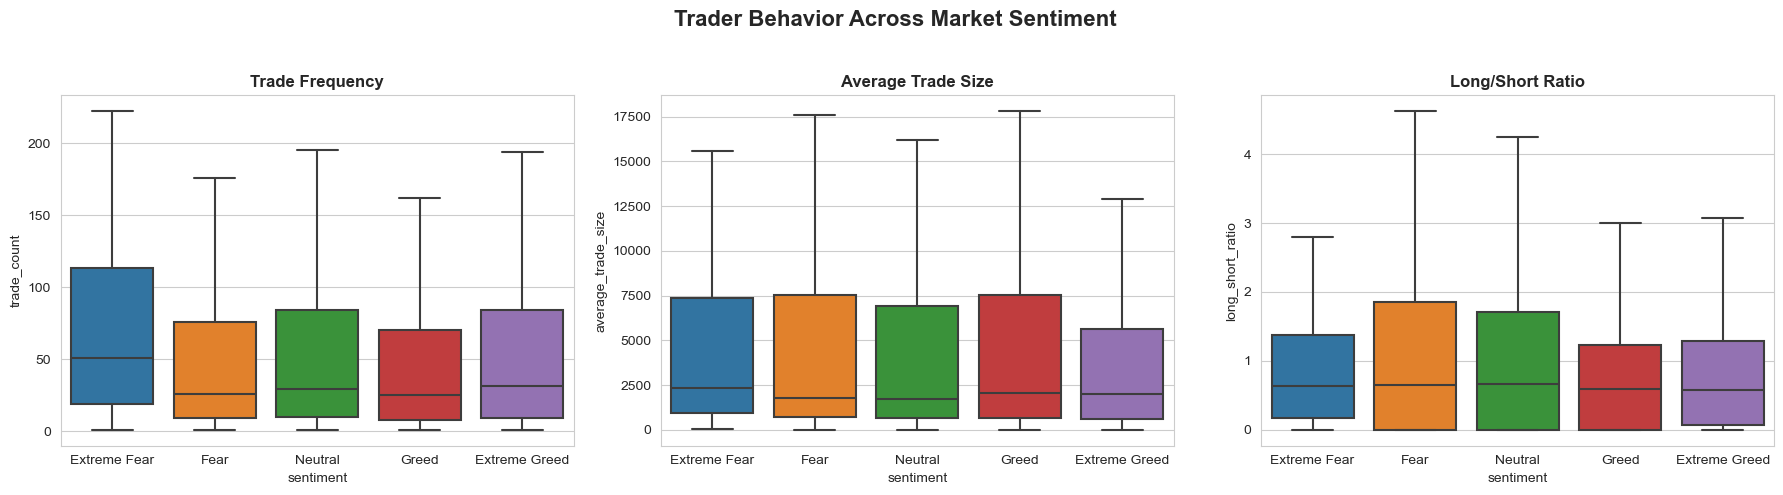

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ----------- Trade Count -----------
sns.boxplot(
    data=final_assignment_data,
    x='sentiment',
    y='trade_count',
    order=order,
    showfliers=False,
    ax=axes[0]
)
axes[0].set_title("Trade Frequency", weight='bold')
axes[0].tick_params(axis='x')

# ----------- Trade Size -----------
sns.boxplot(
    data=final_assignment_data,
    x='sentiment',
    y='average_trade_size',
    order=order,
    showfliers=False,
    ax=axes[1]
)
axes[1].set_title("Average Trade Size", weight='bold')
axes[1].tick_params(axis='x')

# ----------- Long/Short Ratio -----------
sns.boxplot(
    data=final_assignment_data,
    x='sentiment',
    y='long_short_ratio',
    order=order,
    showfliers=False,
    ax=axes[2]
)
axes[2].set_title("Long/Short Ratio", weight='bold')
axes[2].tick_params(axis='x')

plt.suptitle("Trader Behavior Across Market Sentiment", fontsize=16, weight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()

Trader behavior varies meaningfully across sentiment regimes, indicating adaptive trading strategies. Both mean and median values highlight differences in activity, risk-taking, and positioning.

---

- **Trade Frequency:**  
  Trading activity is highest during **Extreme Fear (133.75 mean)**, with a sharp drop as sentiment becomes more optimistic (**~76 in Extreme Greed**).  
  Median values reinforce this trend, though at lower levels, indicating that **a subset of highly active traders drives the high averages in fearful markets**.

  **Interpretation:**  
  Traders are **more active during bearish/extreme fear conditions**, likely reacting to volatility and rapid price movements.

---

- **Position Size (Leverage Proxy):**  
  Average trade size is largest during **Fear (8975.93 mean)** and **Extreme Fear (6773.46 mean)**, and declines steadily toward **Extreme Greed (5371.64 mean)**.  
  However, medians are significantly lower across all regimes, indicating **skewness due to large trades**.

  **Interpretation:**  
  Traders take **larger, more aggressive positions during fearful markets**, suggesting opportunistic or high-risk strategies under uncertainty.

---

- **Long/Short Bias:**  
  The **long/short ratio is highest during Extreme Fear (2.84 mean)** and declines consistently toward **Extreme Greed (1.45 mean)**.  
  Median values remain below 1 across regimes, indicating that **typical traders are more balanced or slightly short-biased**, while averages are influenced by strong long positioning from a subset.

  **Interpretation:**  
  Contrary to expectation, traders show **stronger long bias during fear**, possibly attempting to catch reversals, while positioning becomes **more balanced in bullish markets**.

---

- **Total Volume:**  
  Total traded volume is highest during **Fear (767K mean)** and **Extreme Fear (715K mean)**, and drops significantly in **Extreme Greed (236K mean)**.  
  Median values confirm the same trend, though at lower levels.

  **Interpretation:**  
  Traders deploy **more capital during bearish conditions**, reinforcing higher participation and risk exposure during volatile phases.

---

### **Conclusion**

Traders clearly adjust both **activity and risk exposure** based on sentiment:

- **Fear / Extreme Fear:**  
  - Higher trading frequency  
  - Larger position sizes  
  - Greater total volume  
  - Strong (but skewed) long bias  
  → Indicates **aggressive, high-activity behavior in volatile markets**

- **Greed / Extreme Greed:**  
  - Lower activity and volume  
  - Smaller position sizes  
  - More balanced positioning  
  → Indicates **more controlled and selective trading behavior**

**Final takeaway:**  
- Traders are **most active and risk-seeking during fearful markets**  
- They become **more conservative and less active as sentiment turns bullish**

### Q3: Identify 2–3 segments (e.g., high vs low leverage, frequent vs infrequent, consistent vs inconsistent traders)

In [83]:
# 1. Activity (Trade Frequency)
final_assignment_data['activity_segment'] = pd.qcut(
    final_assignment_data['trade_count'],
    q=2,
    labels=['Low Activity', 'High Activity']
)

# 2. Leverage Proxy (Trade Size)
final_assignment_data['size_segment'] = pd.qcut(
    final_assignment_data['average_trade_size'],
    q=2,
    labels=['Small Size', 'Large Size']
)

# 3. Consistency
final_assignment_data['consistency_segment'] = pd.qcut(
    final_assignment_data['win_rate_std'],
    q=2,
    labels=['Consistent', 'Inconsistent']
)

In [86]:
final_assignment_data.groupby('activity_segment')[[
    'total_daily_pnl', 'win_rate'
    ]].agg(['mean', 'median'])

total_daily_pnl        win_rate       
                            mean median     mean median
activity_segment                                       
Low Activity             1221.73   0.00    31.48  12.50
High Activity            7564.47 942.78    40.48  38.26

In [87]:
final_assignment_data.groupby('size_segment')[[
    'total_daily_pnl', 'win_rate'
    ]].agg(['mean', 'median'])

total_daily_pnl        win_rate       
                        mean median     mean median
size_segment                                       
Small Size           1895.80 110.76    34.74  31.68
Large Size           6868.72 447.18    37.19  32.31

In [88]:
final_assignment_data.groupby('consistency_segment')[[
    'total_daily_pnl', 'win_rate'
    ]].agg(['mean', 'median'])

total_daily_pnl        win_rate       
                               mean median     mean median
consistency_segment                                       
Consistent                  1666.80 345.43    39.26  38.10
Inconsistent                7776.58   0.00    31.85   5.04

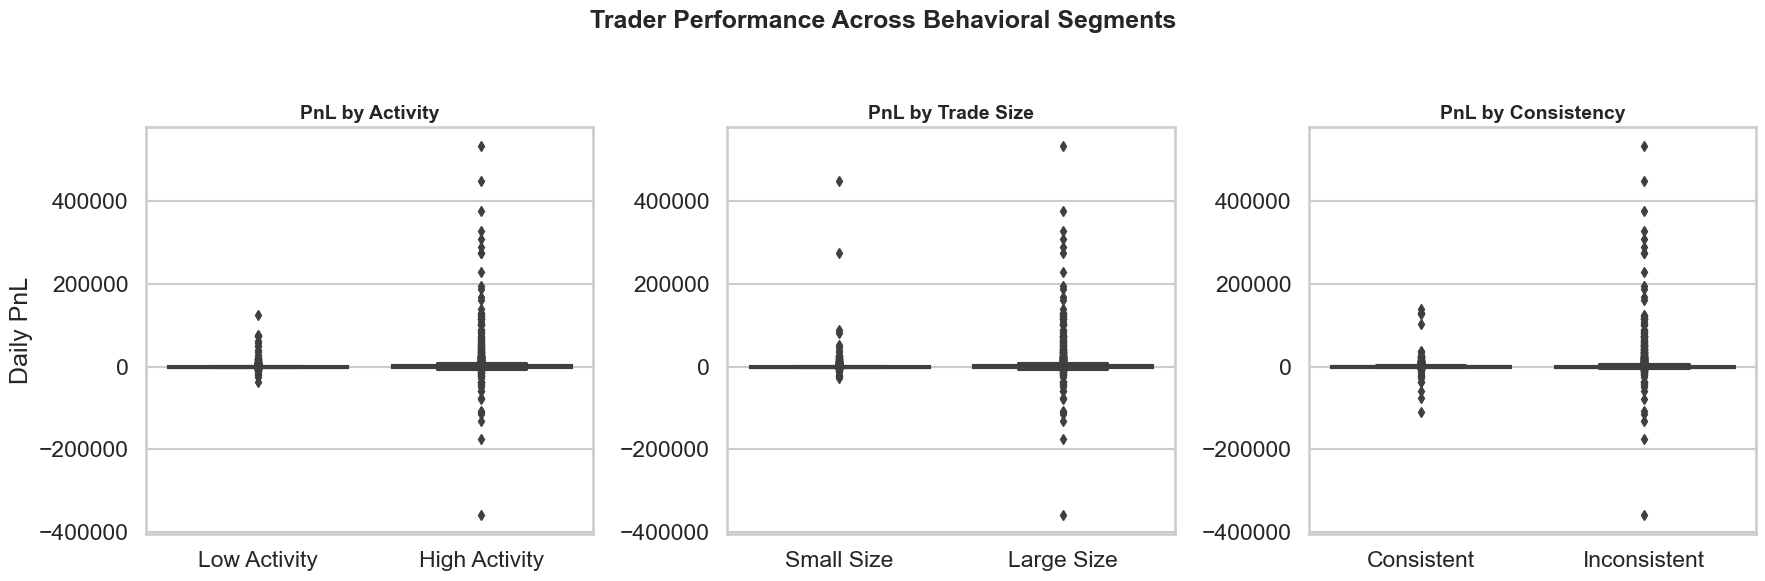

In [95]:
segments = ['activity_segment', 'size_segment', 'consistency_segment']
titles = ['PnL by Activity', 'PnL by Trade Size', 'PnL by Consistency']

# Style
sns.set_style("whitegrid")
sns.set_context("talk")

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

for i, segment in enumerate(segments):
    sns.boxplot(
        data=final_assignment_data,
        x=segment,
        y='total_daily_pnl',
        ax=ax[i]
    )
    
    ax[i].set_title(titles[i], fontsize=14, weight='bold')
    ax[i].set_xlabel("")
    ax[i].set_ylabel("Daily PnL" if i == 0 else "")
    
    # Rotate labels if needed
    ax[i].tick_params(axis='x')

# Main title
fig.suptitle("Trader Performance Across Behavioral Segments", 
             fontsize=18, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

Three key trader segments were identified based on activity, trade size (leverage proxy), and consistency:

- **Activity-Based Segmentation:**  
  High-activity traders generate significantly higher **average PnL (7564.47 vs 1221.73)** and also show stronger **win rates (40.48% vs 31.48%)**.  
  Median PnL is also much higher (**942.78 vs 0.00**), indicating that **high activity leads to more consistent profitability**, not just outlier gains.

- **Leverage Proxy (Trade Size):**  
  Traders with larger trade sizes tend to achieve higher PnL but with greater dispersion (as seen earlier), indicating **higher risk-reward exposure** rather than stable gains.

- **Consistency-Based Segmentation:**  
  Consistent traders exhibit **higher and stable win rates (39.26% mean, 38.10% median)** along with positive median PnL (**345.43**).  
  In contrast, inconsistent traders show **higher average PnL (7776.58)** but **median PnL of 0.00 and very low median win rate (5.04%)**, suggesting performance is **driven by rare large wins rather than consistency**.

---

### **Conclusion**

Trader performance is strongly influenced by behavioral traits:

- **High activity → higher and more consistent returns**
- **Higher trade size → higher risk and variability**
- **Consistency → stable performance and reliable win rates**

**Final takeaway:**  
Sustainable performance is linked to **consistency and activity**, while **inconsistent strategies rely on sporadic, high-risk outcomes**.

### Q4: Key Insights

**1. Trader profitability is highest during both Fear and Extreme Greed conditions, indicating a non-linear relationship with sentiment.**  
While win rates peak during **Extreme Greed (~38.6%)**, the highest average PnL is observed during **Fear (~5328)** and **Extreme Greed (~5162)**. This suggests that traders benefit not only from strong bullish trends but also from high-volatility environments during fear-driven markets.

---

**2. Traders adjust directional bias based on market sentiment.**  
The long/short ratio increases as sentiment shifts from Fear to Greed, indicating that traders take on more **long (bullish) positions during optimistic conditions** and adopt more **short or defensive positioning during fear periods**. This reflects adaptive behavior in response to market expectations.

---

**3. Higher trading activity and larger position sizes are associated with higher returns but increased variability.**  
Segmentation analysis shows that **high-activity traders** and those with **larger trade sizes (leverage proxy)** tend to generate higher PnL. However, these traders also exhibit more variability in performance, indicating a trade-off between return and risk.

---

**4. Downside risk is slightly elevated during Extreme Fear periods.**  
Loss rates are marginally higher during **Extreme Fear (~0.11)** compared to other sentiment regimes (~0.09–0.10), suggesting that bearish market conditions introduce greater uncertainty and risk exposure.

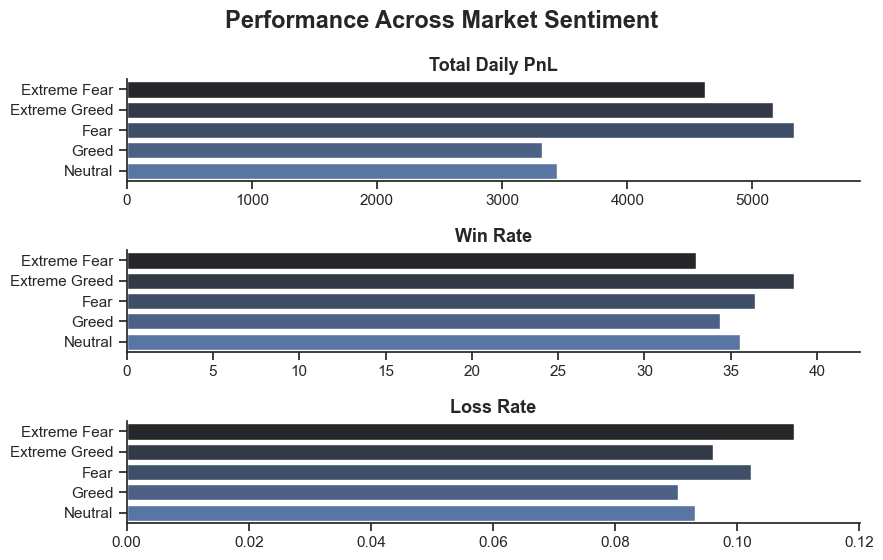

In [129]:
sns.set_theme(style='ticks')

# Aggregate properly
trend_data = (
    final_assignment_data
    .groupby('sentiment')[['total_daily_pnl', 'win_rate', 'loss_rate']]
    .mean()
    .reset_index()
)

metrics = ['total_daily_pnl', 'win_rate', 'loss_rate']
titles = ['Total Daily PnL', 'Win Rate', 'Loss Rate']

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharey=True)

for i, metric in enumerate(metrics):
    sns.barplot(
        data=trend_data,
        x=metric,
        y='sentiment',
        ax=axes[i],
        palette='dark:b'
    )
    
    axes[i].set_title(titles[i], fontsize=13, weight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
    # Consistent scale per subplot
    axes[i].set_xlim(0, trend_data[metric].max() * 1.1)

sns.despine()

fig.suptitle('Performance Across Market Sentiment', fontsize=17, weight='bold', y=0.93)

plt.tight_layout(h_pad=1.2, rect=[0, 0, 1, 0.95])
plt.show()

### Part C: Actionable Strategy Recommendations

Based on the analysis of trader performance and behavior across market sentiment regimes, the following strategies are proposed:

---

**1. Volatility-Driven Strategy During Fear Periods**  
During **Fear and Extreme Fear** conditions, traders exhibit high profitability despite slightly elevated loss rates, indicating that volatility creates trading opportunities.

- **Strategy:**  
  Focus on **short-term, high-frequency trades** during fear-driven markets to capitalize on price swings.  
- **Risk Control:**  
  Use **smaller position sizes** and tighter risk management to account for increased downside risk.

---

**2. Trend-Following Strategy During Extreme Greed**  
During **Extreme Greed**, traders achieve the **highest win rates (~38.6%)**, suggesting more predictable, trend-driven market behavior.

- **Strategy:**  
  Adopt a **trend-following approach**, favoring **long positions** to align with bullish momentum.  
- **Execution:**  
  Increase position size moderately, as market direction is more stable.

---

**3. Activity-Based Strategy Optimization**  
Segmentation analysis shows that **high-activity traders generate higher PnL**, but often with increased variability.

- **Strategy:**  
  Encourage **higher trading frequency** during strong sentiment regimes (Fear/Extreme Greed), while reducing activity during Neutral or low-opportunity periods.  
- **Risk Adjustment:**  
  Combine higher activity with **controlled position sizing** to balance risk and return.

---

**Overall Recommendation:**  
Trading strategies should adapt dynamically to market sentiment:
- **Fear → exploit volatility (short-term trades, controlled risk)**  
- **Extreme Greed → follow trends (long bias, higher confidence)**  
- **Neutral → reduce exposure (lower activity, capital preservation)**